# Prepare Test Data for CNN Model

This notebook prepares the new IMU data in the exact same format as the training data.

**Input:** `IMU_devX_all_tasks.csv` (resampled to 60 Hz, labeled)

**Output:** `X_test_new.npy` (N_windows × 60 × 12) and `y_test_new.npy` (N_windows,)

**Column order (must match training):**
ankleL_q0-3 | ankleR_q0-3 | back_q0-3

## 1. Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Parameters
Must match exactly what was used during training.

In [10]:
# Segmentation — must match training
W  = 1       # window size in seconds
O  = 0.75    # overlap
FS = 60      # Hz

# Device mapping (based on data analysis)
# !! Confirm with supervisor before running !!
DEV_ANKLE_L = 'dev7'   # ankleL
DEV_ANKLE_R = 'dev2'   # ankleR
DEV_BACK    = 'dev3'   # back

# Quaternion column names in the CSV files
QUAT_COLS = ['quat_w', 'quat_x', 'quat_y', 'quat_z']

# Output files
OUTPUT_X = 'X_test_new.npy'
OUTPUT_Y = 'y_test_new.npy'

WIN_SIZE = int(W * FS)
STEP     = int(WIN_SIZE * (1 - O))
print(f"Window size : {WIN_SIZE} samples ({W}s)")
print(f"Step        : {STEP} samples (overlap={O*100:.0f}%)")

Window size : 60 samples (1s)
Step        : 15 samples (overlap=75%)


## 3. Load and align the three devices

In [11]:
df_ankleL = pd.read_csv(f'IMU_{DEV_ANKLE_L}_all_tasks.csv')
df_ankleR = pd.read_csv(f'IMU_{DEV_ANKLE_R}_all_tasks.csv')
df_back   = pd.read_csv(f'IMU_{DEV_BACK}_all_tasks.csv')

print(f"ankleL ({DEV_ANKLE_L}): {len(df_ankleL)} samples")
print(f"ankleR ({DEV_ANKLE_R}): {len(df_ankleR)} samples")
print(f"back   ({DEV_BACK})  : {len(df_back)} samples")

# Trim all to the same length (small differences due to timestamp jitter are normal)
min_len = min(len(df_ankleL), len(df_ankleR), len(df_back))
df_ankleL = df_ankleL.iloc[:min_len].reset_index(drop=True)
df_ankleR = df_ankleR.iloc[:min_len].reset_index(drop=True)
df_back   = df_back.iloc[:min_len].reset_index(drop=True)
print(f"Trimmed to {min_len} samples (difference was at most {max(len(df_ankleL), len(df_ankleR), len(df_back)) - min_len} samples)")
print("All devices aligned ✓")

ankleL (dev7): 236859 samples
ankleR (dev2): 236859 samples
back   (dev3)  : 236856 samples
Trimmed to 236856 samples (difference was at most 0 samples)
All devices aligned ✓


## 4. Build the combined DataFrame
Column order must match training exactly:
`ankleL_q0-3 | ankleR_q0-3 | back_q0-3`

In [12]:
df_combined = pd.DataFrame({
    # ankleL quaternions
    'ankleL_q0': df_ankleL['quat_w'].values,
    'ankleL_q1': df_ankleL['quat_x'].values,
    'ankleL_q2': df_ankleL['quat_y'].values,
    'ankleL_q3': df_ankleL['quat_z'].values,
    # ankleR quaternions
    'ankleR_q0': df_ankleR['quat_w'].values,
    'ankleR_q1': df_ankleR['quat_x'].values,
    'ankleR_q2': df_ankleR['quat_y'].values,
    'ankleR_q3': df_ankleR['quat_z'].values,
    # back quaternions
    'back_q0': df_back['quat_w'].values,
    'back_q1': df_back['quat_x'].values,
    'back_q2': df_back['quat_y'].values,
    'back_q3': df_back['quat_z'].values,
    # labels and metadata
    'fog'      : df_back['fog_label'].values,
    'task_name': df_back['task_name'].values,
})

print(f"Combined DataFrame shape: {df_combined.shape}")
print(f"FOG samples: {df_combined['fog'].sum()} ({100*df_combined['fog'].mean():.1f}%)")
print(f"\nFirst rows:")
df_combined.head()

Combined DataFrame shape: (236856, 14)
FOG samples: 7688 (3.2%)

First rows:


,ankleL_q0,ankleL_q1,ankleL_q2,ankleL_q3,ankleR_q0,ankleR_q1,ankleR_q2,ankleR_q3,back_q0,back_q1,back_q2,back_q3,fog,task_name
0,0.565796,-0.115356,0.094727,0.810974,0.422485,-0.148499,-0.017456,0.893982,0.806885,-0.070618,0.328979,0.485535,0,task_stop_FOG003
1,0.565796,-0.115356,0.094727,0.810974,0.422485,-0.148315,-0.017436,0.893982,0.806979,-0.070994,0.328885,0.485346,0,task_stop_FOG003
2,0.565796,-0.115356,0.094727,0.810974,0.422485,-0.148315,-0.017355,0.893982,0.807093,-0.071461,0.328710,0.485217,0,task_stop_FOG003
3,0.565796,-0.115356,0.094727,0.810974,0.422485,-0.148256,-0.017334,0.893982,0.807195,-0.071681,0.328603,0.485158,0,task_stop_FOG003
4,0.565796,-0.115356,0.094727,0.810974,0.422485,-0.148185,-0.017334,0.893982,0.807226,-0.071836,0.328541,0.485096,0,task_stop_FOG003


## 5. Segment into windows
Exact same logic as training: relative transformation + mode label.

In [13]:
COLS = [
    'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
    'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
    'back_q0',   'back_q1',   'back_q2',   'back_q3'
]

def segment_data(df, w=W, o=O, fs=FS):
    win_size = int(w * fs)
    step     = int(win_size * (1 - o))
    
    data   = df[COLS].values
    labels = df['fog'].values
    
    X, y = [], []
    
    for i in range(0, len(data) - win_size, step):
        window = data[i : i + win_size]
        
        # Relative transformation — same as training
        window_rel = window - window[0]
        X.append(window_rel)
        
        # Mode label
        y.append(pd.Series(labels[i : i + win_size]).mode()[0])
    
    return np.array(X), np.array(y)


print("Segmenting...")
X_test, y_test = segment_data(df_combined)

print(f"\nX_test shape : {X_test.shape}  (windows × timesteps × channels)")
print(f"y_test shape : {y_test.shape}")
print(f"FOG windows  : {y_test.sum()} ({100*y_test.mean():.1f}%)")
print(f"Non-FOG      : {(y_test==0).sum()} ({100*(y_test==0).mean():.1f}%)")

Segmenting...

X_test shape : (15787, 60, 12)  (windows × timesteps × channels)
y_test shape : (15787,)
FOG windows  : 534 (3.4%)
Non-FOG      : 15253 (96.6%)


## 6. Save

In [14]:
np.save(OUTPUT_X, X_test)
np.save(OUTPUT_Y, y_test)
print(f"Saved: {OUTPUT_X}  {X_test.shape}")
print(f"Saved: {OUTPUT_Y}  {y_test.shape}")

Saved: X_test_new.npy  (15787, 60, 12)
Saved: y_test_new.npy  (15787,)


## 7. Quick sanity check
Compare value ranges with what the model expects.

In [15]:
print("Value ranges per channel group (after relative transform):")
groups = {'ankleL': range(0,4), 'ankleR': range(4,8), 'back': range(8,12)}

for name, idx in groups.items():
    vals = X_test[:, :, list(idx)]
    print(f"  {name}: min={vals.min():.3f} max={vals.max():.3f} mean={vals.mean():.3f} std={vals.std():.3f}")

# Verify quaternion norm before relative transform (should be ~1)
print("\nQuaternion norms BEFORE relative transform (should be ~1.0):")
for name, cols in [('ankleL', ['ankleL_q0','ankleL_q1','ankleL_q2','ankleL_q3']),
                   ('ankleR', ['ankleR_q0','ankleR_q1','ankleR_q2','ankleR_q3']),
                   ('back',   ['back_q0','back_q1','back_q2','back_q3'])]:
    norms = np.sqrt((df_combined[cols].values**2).sum(axis=1))
    print(f"  {name}: mean norm = {norms.mean():.4f} ± {norms.std():.4f}")

Value ranges per channel group (after relative transform):
  ankleL: min=-1.068 max=1.769 mean=-0.000 std=0.072
  ankleR: min=-1.105 max=1.907 mean=-0.000 std=0.068
  back: min=-0.915 max=1.590 mean=-0.000 std=0.044

Quaternion norms BEFORE relative transform (should be ~1.0):
  ankleL: mean norm = 1.0000 ± 0.0001
  ankleR: mean norm = 1.0000 ± 0.0002
  back: mean norm = 1.0000 ± 0.0000


## 8. Visual check — one FOG window

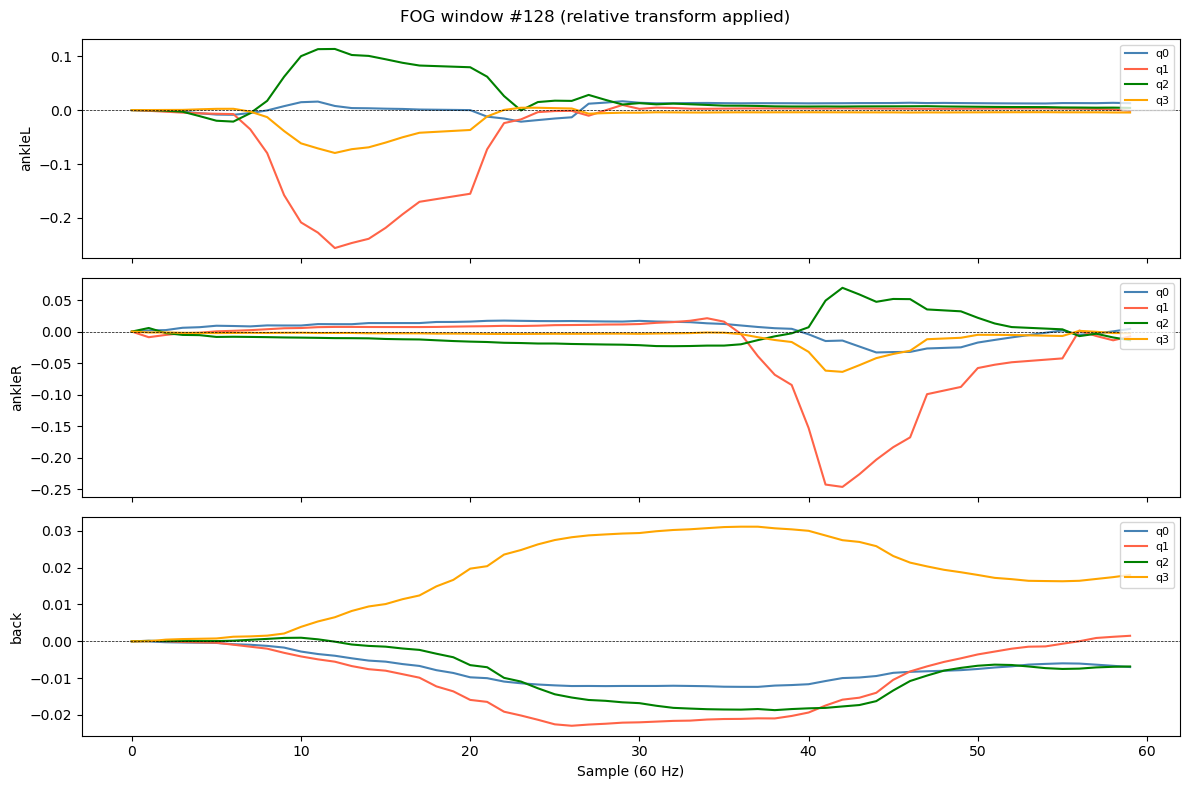

Showing FOG window 128 out of 534 total FOG windows


In [16]:
fog_indices = np.where(y_test == 1)[0]

if len(fog_indices) == 0:
    print("No FOG windows found — check labels")
else:
    idx = fog_indices[0]
    window = X_test[idx]  # shape (60, 12)
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    labels_plot = ['ankleL q0-3', 'ankleR q0-3', 'back q0-3']
    colors = ['steelblue', 'tomato', 'green', 'orange']
    
    for ax, (name, start) in zip(axes, [('ankleL', 0), ('ankleR', 4), ('back', 8)]):
        for j, c in enumerate(colors):
            ax.plot(window[:, start+j], color=c, label=f'q{j}')
        ax.set_ylabel(name)
        ax.legend(loc='upper right', fontsize=8)
        ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    
    axes[-1].set_xlabel('Sample (60 Hz)')
    plt.suptitle(f'FOG window #{idx} (relative transform applied)', fontsize=12)
    plt.tight_layout()
    plt.savefig('fog_window_check.png', dpi=150)
    plt.show()
    print(f"Showing FOG window {idx} out of {len(fog_indices)} total FOG windows")